In [1]:

import torch
import numpy as np
from tqdm.autonotebook import tqdm
from matplotlib import pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import warnings
import copy
from collections import deque
from torch.distributions import Categorical
import pandas as pd

try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False

from model import *
from utils import *
from env import *
from ppo import *

log_wandb = False

import datetime


now = datetime.datetime.now()   
curr_time = now.strftime("%H_%M_%S")
curr_date = now.strftime("%d_%m_%Y")
curr_date_time = str('d_')+curr_date+str('_t_')+curr_time

C:\Users\anike\AppData\Local\Temp\ipykernel_22640\1073539825.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
PROJECT_NAME = "Bio Env"
# RUN_NAME = (
#     EXPERIMENT_PARAMS["AGENT_NAME"]
#     + "_Run_" + str(EXPERIMENT_PARAMS["RUN_NUM"])
#     + "_Seed_" + str(EXPERIMENT_PARAMS["SEED"])
# )

RUN_NAME = "Run 3"
if log_wandb:
    print(f'Running project {PROJECT_NAME}, run {RUN_NAME} on wandb at curr date and time {curr_date_time}')
    wandb.init(
            project=PROJECT_NAME,
            name=RUN_NAME,
            # config={
            #     "experiment_params": EXPERIMENT_PARAMS,
            #     "agent": AGENT_NAME,
            #     "agent_args": AGENT_ARGS,
            #     "training_params": TRAINING_PARAMS,
            #     "env_args": ENV_AGRS,
            #     "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            #     "file_path": FILE_PATH,
            #     "datetime": curr_date_time,
            # }
            )

In [3]:
import os
import numpy as np
from env import FoodEnv
from ppo import PPOAgent

# ──────────────────────────────────────────────────────────────────────────────
# Quick smoke-test  (python main.py)
# ──────────────────────────────────────────────────────────────────────────────

# ── Config ────────────────────────────────────────────────────────────────
FOOD_FOLDER = "foods_dataset"
PLOT_DIR    = "plots"
MENU_SIZE   = 2
MAX_STEPS   = 480       # 480 steps × 2 min/step ≈ 16 hrs
SEED        = 0
log_wandb   = False

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Environment ───────────────────────────────────────────────────────────
env = FoodEnv(
    food_folder=FOOD_FOLDER,
    num_foods=MENU_SIZE,
    max_steps=MAX_STEPS,
    one_hot_embedding=True,
    seed=SEED,
)

print("\n── Environment summary ──────────────────────────────────────")
print(f"  Food items      : {env.num_items}")
print(f"  Nutrients       : {env.num_nutrients}  {env.nutrient_names}")
# Continuous action space: Box(num_foods,) — one amount in [0,1] per menu slot
print(f"  Menu size       : {env.num_foods}  (continuous amounts → action shape {env.action_space.shape})")
print(f"  Max steps       : {env.max_steps}")
print(f"  Target (normed) : {env._norm_targets}")
print(f"  Target low      : {env._norm_target_low}")
print(f"  Target high     : {env._norm_target_high}")
print()
print(env.nutrient_norm_summary().to_string(index=False))
print("─────────────────────────────────────────────────────────────\n")

# ── Agent ─────────────────────────────────────────────────────────────────
agent = PPOAgent(env, device="cpu", shared=False, seed=42, limit_delta=1.0)

# ── Train ─────────────────────────────────────────────────────────────────
NUM_EPISODES = 750
print(f"Starting training: {NUM_EPISODES} episodes …")

returns, consumption = agent.train(
    num_episodes=NUM_EPISODES,
    rollout_steps=128,
    ppo_epochs=4,
    minibatch_size=32,
    log_every_episodes=100,
    printing=True,
    actor_lr=1e-4,
    critic_lr=1e-2,
    log_wandb=log_wandb,
)

print(f"\nDone.")
print(f"  Final rolling avg return      (last 50): {np.mean(returns[-50:]):.3f}")
print(f"  Final rolling avg consumption (last 50): {np.mean(consumption[-50:]):.3f}")

[FoodEnv] Loading  'glucose'  from  'foods_dataset\serum_glucose.csv'
           min=0.0000  max=153.4313   foods=28   time_points=500
[FoodEnv] Loading  'peptides'  from  'foods_dataset\small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=28   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  'foods_dataset\fatty_acids_absorbed.csv'
           min=0.0000  max=0.0049   foods=28   time_points=500
[FoodEnv] Ready — 28 foods | 3 time-series nutrients | 0 cumulative nutrients

── Environment summary ──────────────────────────────────────
  Food items      : 28
  Nutrients       : 3  ['glucose', 'peptides', 'fatty_acids']
  Menu size       : 2  (continuous amounts → action shape (2,))
  Max steps       : 480
  Target (normed) : [0.65175766 0.5586592  0.06804124]
  Target low      : [0.45623037 0.2793296  0.0371134 ]
  Target high     : [0.847285   0.83798885 0.09896907]

   nutrient  data_min  data_max  raw_target  normalised_target  window_size  decay_rate  reward_w


Running greedy evaluation episode for plots …
  Saved evaluation_summary.png
  Saved digestion_dynamics.png

All plots saved to 'plots/'


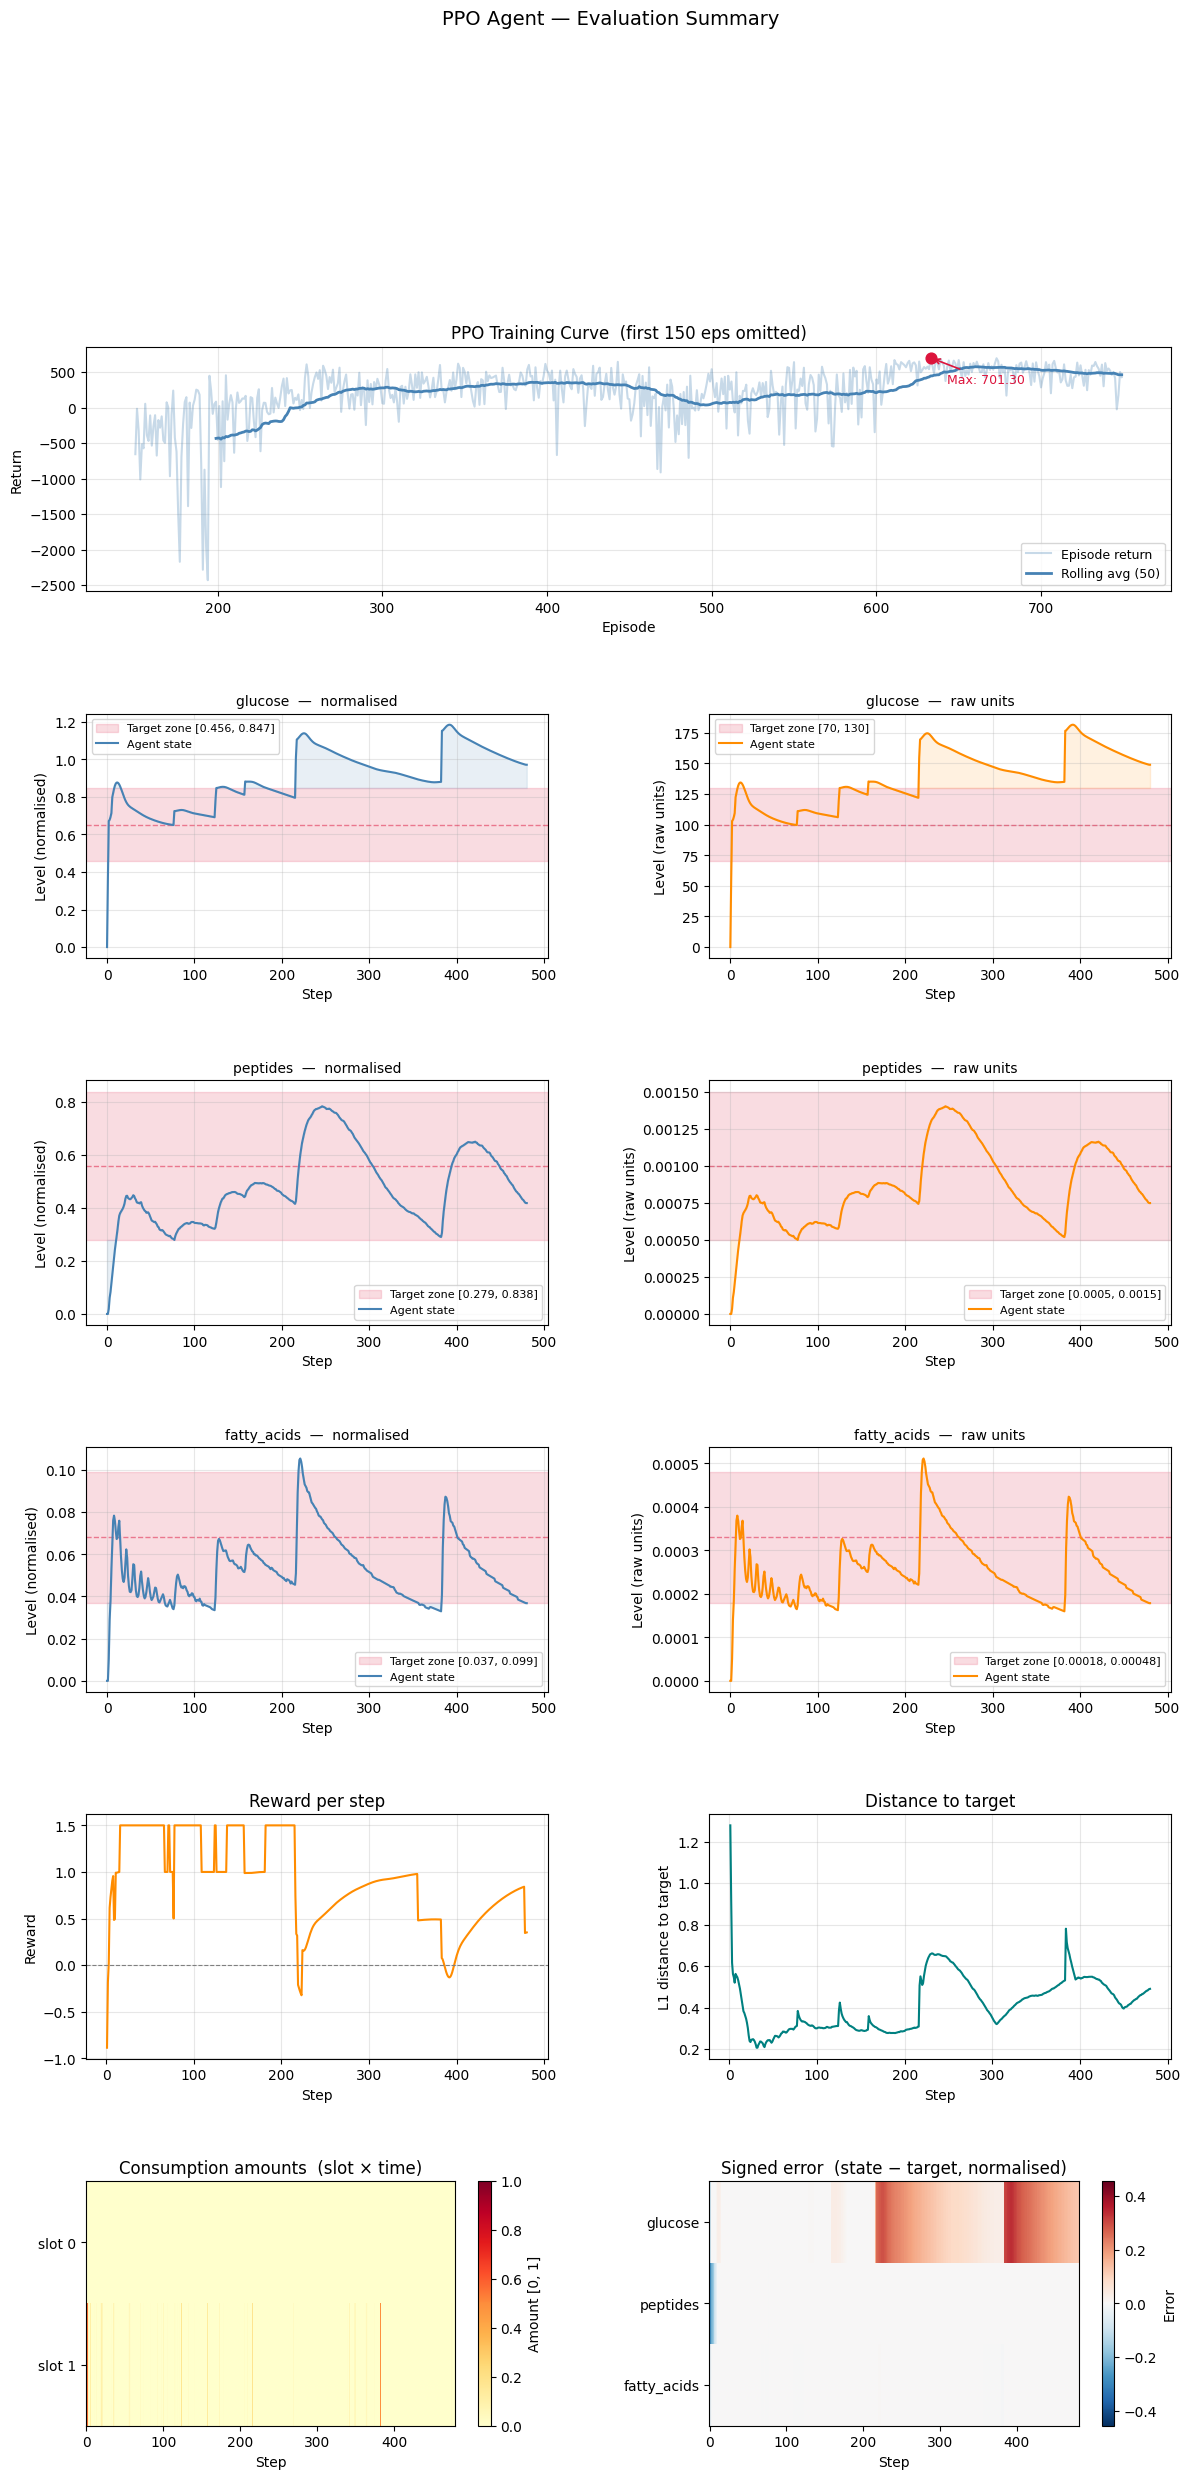

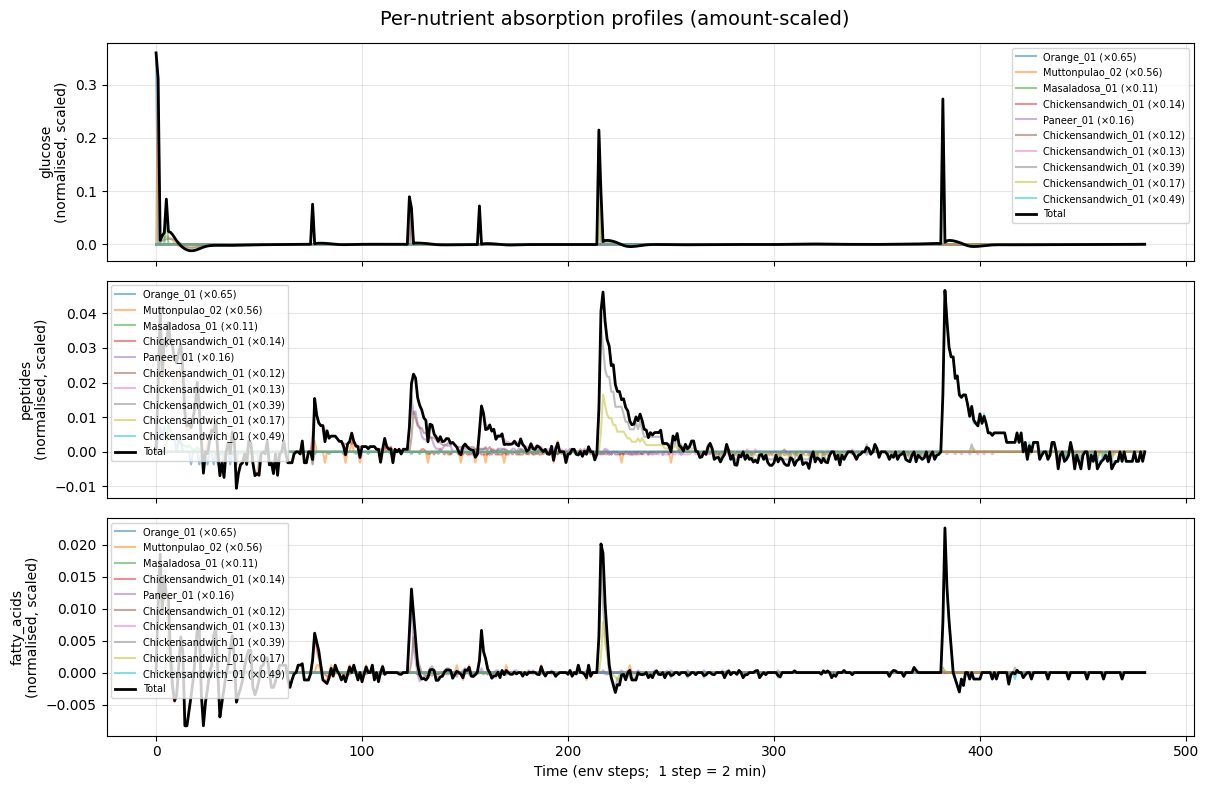

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Post-training: run one greedy episode for diagnostics
# ──────────────────────────────────────────────────────────────────────────────
print("\nRunning greedy evaluation episode for plots …")
memory, episode_df = agent.generate_episode(log_wandb=log_wandb)
 
T     = len(episode_df)
n     = env.num_nutrients
names = env.nutrient_names
 
# ── Reconstruct state trajectory (T+1, N) ────────────────────────────────
# generate_episode already stores the state at each step; repeat the last
# row as a terminal placeholder to keep t_axis length = T+1.
states = np.vstack([
    episode_df[list(names)].values,
    episode_df[list(names)].iloc[[-1]].values,
])  # (T+1, N)
 
rewards   = episode_df["reward"].values    # (T,)
distances = episode_df["distance"].values  # (T,)
 
# Per-slot consumption amounts: columns are amount_slot_0 … amount_slot_{K-1}
amounts_arr = np.stack(
    [episode_df[f"amount_slot_{i}"].values for i in range(env.num_foods)],
    axis=1,
)  # (T, num_foods)
 
# ── Normalised boundaries ─────────────────────────────────────────────────
target_norm = env._norm_targets      # (N,)
norm_low    = env._norm_target_low   # (N,)
norm_high   = env._norm_target_high  # (N,)
 
# ── Unnormalise: x_raw = x_norm * (max - min) + min ─────────────────────
unnorm_states  = np.zeros_like(states)
unnorm_targets = np.zeros(n, dtype=np.float32)
unnorm_low     = np.zeros(n, dtype=np.float32)
unnorm_high    = np.zeros(n, dtype=np.float32)
 
for i, nm in enumerate(names):
    v_min = env._nutrient_mins[nm]
    v_max = env._nutrient_maxs[nm]
    rng   = v_max - v_min
    unnorm_states[:, i] = states[:, i] * rng + v_min
    unnorm_targets[i]   = target_norm[i] * rng + v_min
    unnorm_low[i]       = norm_low[i]  * rng + v_min
    unnorm_high[i]      = norm_high[i] * rng + v_min
 
t_axis = np.arange(T + 1)   # 0 … T  (length T+1, matches states rows)
t_step = np.arange(1, T + 1) # 1 … T  (length T,  matches rewards/distances)
 
# ──────────────────────────────────────────────────────────────────────────────
# Single consolidated figure
# Layout rows:
#   0        : training curve (full width)
#   1 … N    : normalised | unnormalised state per nutrient
#   N+1      : reward | L1 distance
#   N+2      : consumption heatmap (slot × time) | signed error heatmap
# ──────────────────────────────────────────────────────────────────────────────
SKIP_EPS = 150   # drop first N episodes from training curve (noisy early phase)
WINDOW   = 50   # rolling average window
 
n_rows = n + 3
fig = plt.figure(figsize=(14, 4.5 * n_rows))
gs  = gridspec.GridSpec(n_rows, 2, figure=fig, hspace=0.5, wspace=0.35)
 
# ── Row 0: training curve (full width) ───────────────────────────────────
ax_tr        = fig.add_subplot(gs[0, :])
plot_returns  = returns[SKIP_EPS:]
plot_episodes = np.arange(SKIP_EPS, len(returns))
rolling       = np.convolve(plot_returns, np.ones(WINDOW) / WINDOW, mode="valid")
roll_x        = np.arange(SKIP_EPS + WINDOW - 1, len(returns))
 
ax_tr.plot(plot_episodes, plot_returns, alpha=0.3, color="steelblue", label="Episode return")
ax_tr.plot(roll_x, rolling, color="steelblue", lw=2, label=f"Rolling avg ({WINDOW})")
 
max_ret = float(np.max(returns))
max_ep  = int(np.argmax(returns))
ax_tr.scatter([max_ep], [max_ret], color="crimson", zorder=5, s=60)
ax_tr.annotate(
    f"Max: {max_ret:.2f}",
    xy=(max_ep, max_ret),
    xytext=(12, -18), textcoords="offset points",
    color="crimson", fontsize=9,
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2),
)
ax_tr.set_xlabel("Episode")
ax_tr.set_ylabel("Return")
ax_tr.set_title(f"PPO Training Curve  (first {SKIP_EPS} eps omitted)")
ax_tr.legend(fontsize=9)
ax_tr.grid(True, alpha=0.3)
 
# ── Rows 1…N: normalised | unnormalised state per nutrient ───────────────
for i, nm in enumerate(names):
    row = i + 1
 
    # Normalised
    ax_n = fig.add_subplot(gs[row, 0])
    ax_n.axhspan(norm_low[i], norm_high[i], alpha=0.15, color="crimson",
                 label=f"Target zone [{norm_low[i]:.3f}, {norm_high[i]:.3f}]")
    ax_n.axhline(target_norm[i], ls="--", color="crimson", lw=1.0, alpha=0.5)
    ax_n.plot(t_axis, states[:, i], color="steelblue", lw=1.5, label="Agent state")
    ref_n = np.clip(states[:, i], norm_low[i], norm_high[i])
    ax_n.fill_between(t_axis, states[:, i], ref_n, alpha=0.12, color="steelblue")
    ax_n.set_title(f"{nm}  —  normalised", fontsize=10)
    ax_n.set_xlabel("Step")
    ax_n.set_ylabel("Level (normalised)")
    ax_n.legend(fontsize=8)
    ax_n.grid(True, alpha=0.3)
 
    # Unnormalised
    ax_u = fig.add_subplot(gs[row, 1])
    ax_u.axhspan(unnorm_low[i], unnorm_high[i], alpha=0.15, color="crimson",
                 label=f"Target zone [{unnorm_low[i]:.4g}, {unnorm_high[i]:.4g}]")
    ax_u.axhline(unnorm_targets[i], ls="--", color="crimson", lw=1.0, alpha=0.5)
    ax_u.plot(t_axis, unnorm_states[:, i], color="darkorange", lw=1.5, label="Agent state")
    ref_u = np.clip(unnorm_states[:, i], unnorm_low[i], unnorm_high[i])
    ax_u.fill_between(t_axis, unnorm_states[:, i], ref_u, alpha=0.12, color="darkorange")
    ax_u.set_title(f"{nm}  —  raw units", fontsize=10)
    ax_u.set_xlabel("Step")
    ax_u.set_ylabel("Level (raw units)")
    ax_u.legend(fontsize=8)
    ax_u.grid(True, alpha=0.3)
 
# ── Row N+1: reward | L1 distance ────────────────────────────────────────
ax_r = fig.add_subplot(gs[n + 1, 0])
ax_r.plot(t_step, rewards, color="darkorange", lw=1.5)
ax_r.axhline(0, color="grey", lw=0.8, ls="--")
ax_r.set_ylabel("Reward")
ax_r.set_xlabel("Step")
ax_r.set_title("Reward per step")
ax_r.grid(True, alpha=0.3)
 
ax_d = fig.add_subplot(gs[n + 1, 1])
ax_d.plot(t_step, distances, color="teal", lw=1.5)
ax_d.set_ylabel("L1 distance to target")
ax_d.set_xlabel("Step")
ax_d.set_title("Distance to target")
ax_d.grid(True, alpha=0.3)
 
# ── Row N+2: consumption heatmap | signed error heatmap ──────────────────
#
# LEFT — consumption heatmap (slot × timestep)
# Shows how much of each food slot the agent consumed at every step.
# Replaces the old action-frequency bar chart since actions are now continuous.
ax_ch = fig.add_subplot(gs[n + 2, 0])
im_c = ax_ch.imshow(
    amounts_arr.T,          # (num_foods, T) — slots on y-axis, time on x-axis
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
)
ax_ch.set_yticks(range(env.num_foods))
ax_ch.set_yticklabels([f"slot {i}" for i in range(env.num_foods)])
ax_ch.set_xlabel("Step")
ax_ch.set_title("Consumption amounts  (slot × time)")
plt.colorbar(im_c, ax=ax_ch, label="Amount [0, 1]")
 
# RIGHT — signed range error heatmap (unchanged from discrete version)
# 0 inside the acceptable zone, negative below, positive above.
below = np.minimum(0.0, states - norm_low[None, :])   # (T+1, N) ≤ 0
above = np.maximum(0.0, states - norm_high[None, :])  # (T+1, N) ≥ 0
error = below + above
 
ax_h = fig.add_subplot(gs[n + 2, 1])
im   = ax_h.imshow(
    error.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(error).max(),
    vmax=np.abs(error).max(),
    interpolation="nearest",
)
ax_h.set_yticks(range(n))
ax_h.set_yticklabels(names)
ax_h.set_xlabel("Step")
ax_h.set_title("Signed error  (state − target, normalised)")
plt.colorbar(im, ax=ax_h, label="Error")
 
fig.suptitle("PPO Agent — Evaluation Summary", fontsize=14, y=1.005)
fig.savefig(os.path.join(PLOT_DIR, "evaluation_summary.png"), bbox_inches="tight")
print("  Saved evaluation_summary.png")
 
# ── Digestion dynamics — separate figure (env built-in) ──────────────────
fig_dig = env.plot_consumption()
fig_dig.savefig(os.path.join(PLOT_DIR, "digestion_dynamics.png"), bbox_inches="tight")
print("  Saved digestion_dynamics.png")
 
print(f"\nAll plots saved to '{PLOT_DIR}/'")
plt.show()